  0%|          | 0/9 [00:00<?, ?it/s]/tmp/ipykernel_23250/1429509024.py:98: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
 11%|█         | 1/9 [00:00<00:03,  2.02it/s]/tmp/ipykernel_23250/1429509024.py:98: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
 22%|██▏       | 2/9 [00:01<00:03,  1.93it/s]/tmp/ipykernel_23250/1429509024.py:98: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
 33%|███▎      | 3/9 [00:01<00:03,  1.80it/s]/tmp/ipykernel_23250/1429509024.py:98: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
 44%|████▍     | 4/9 [00:02<00:02,  1.88it/s]/tmp/ipykernel_23250/1429509024

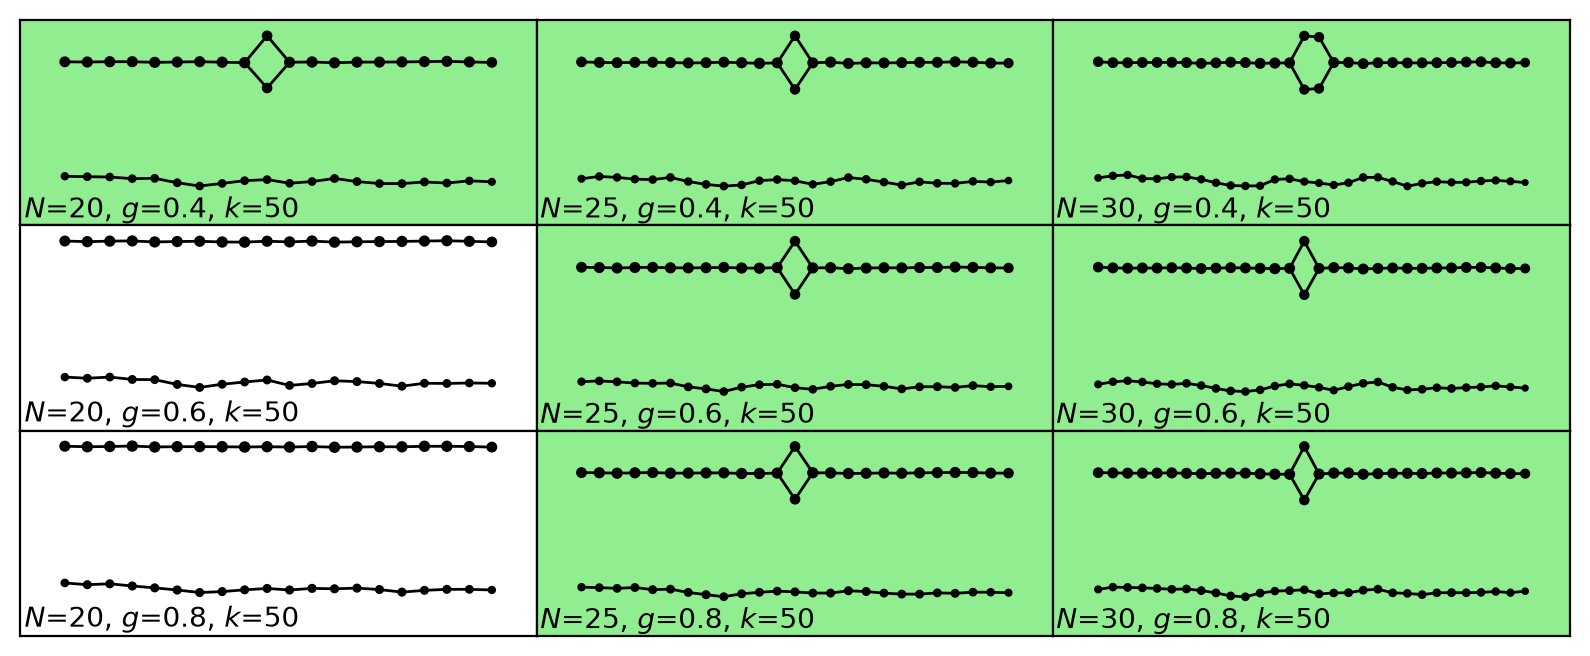

  0%|          | 0/9 [00:00<?, ?it/s]/tmp/ipykernel_23250/1429509024.py:147: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
 11%|█         | 1/9 [00:00<00:02,  3.92it/s]/tmp/ipykernel_23250/1429509024.py:147: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
 22%|██▏       | 2/9 [00:00<00:01,  3.52it/s]/tmp/ipykernel_23250/1429509024.py:147: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
 33%|███▎      | 3/9 [00:00<00:01,  3.09it/s]/tmp/ipykernel_23250/1429509024.py:147: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
 44%|████▍     | 4/9 [00:01<00:01,  3.28it/s]/tmp/ipykernel_23250/142950

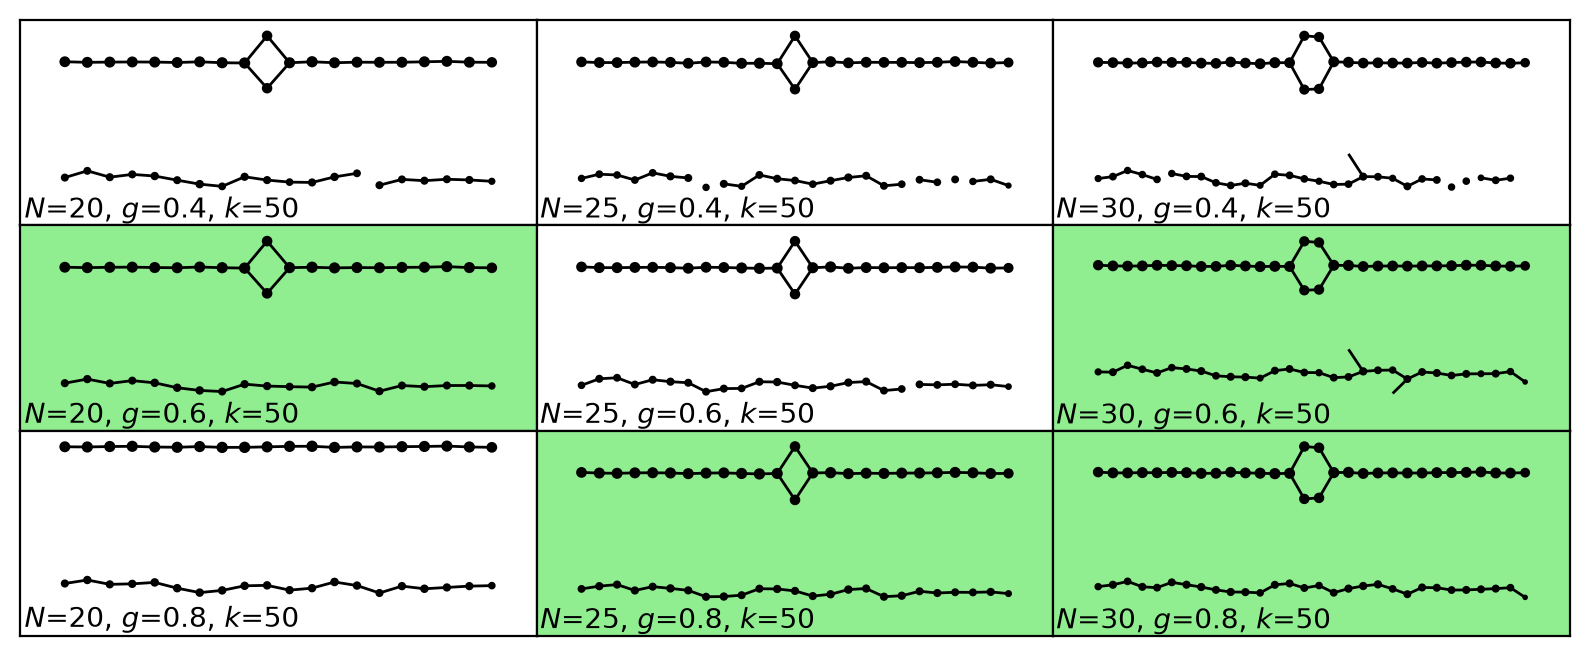

In [17]:
import numpy as np
import pandas as pd
import datamapplot
import sys
import os
import networkx as nx
import temporalmapper as tm
import temporalmapper.plotting as tmutils
import temporalmapper.kernels as tmwc
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
from tqdm import trange

data_time = np.load("data/genus1_demo.npy")
data_unsort = data_time[:,1].T
timestamps_unsort = data_time[:,0].T
sorted_indices = np.argsort(timestamps_unsort)
data = data_unsort[sorted_indices]
timestamps = timestamps_unsort[sorted_indices]
N_data = np.size(timestamps)
map_data = y_data = data

def generate_plot(TG, label_edges = True,ax=None, threshold = 0.2, vertices = None):
    self = TG
    if ax is None:
        ax = plt.gca()
    if type(vertices) == type(None):
        vertices = self.graph.nodes()

    G = self.graph.subgraph(vertices)
    pos = {}
    slice_no = nx.get_node_attributes(TG.graph, 'slice_no')
    for node in vertices:
        t = slice_no[node]
        pt_idx = TG.get_vertex_data(node)
        w = TG.weights[t,pt_idx]
        node_ypos = np.average(np.squeeze(TG.data[pt_idx]))#,weights=w)
        node_xpos = t #np.average(TG.time[pt_idx],weights=w)
        pos[node] = (node_xpos, node_ypos)

    edge_width = np.array([d["weight"] for (u,v,d) in G.edges(data = True)])
    elarge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] >= threshold]
    esmall = [(u, v) for (u, v, d) in G.edges(data=True) if 0.1< d["weight"] < threshold]
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=elarge, width=1, arrows=False)
    if label_edges:
        edge_labels = nx.get_edge_attributes(G, "weight")
        nx.draw_networkx_edge_labels(G, pos, edge_labels)

    node_size = [np.log2(np.size(self.get_vertex_data(node))) for node in vertices]
    clr_dict = nx.get_node_attributes(self.graph, 'cluster_no')
    #node_clr = [clr_dict[node] for node in vertices]

    nx.draw_networkx_nodes(G, pos, ax=ax,node_size=node_size, node_color='k')
    return ax

"""
Running standard mapper over a range of parameters, with Single-Linkage clustering.
"""

checkpoint_numbers = [20,25,30]
overlap_parameters = [0.4,0.6,0.8]
threshold = 0.75


N_plots = len(checkpoint_numbers)*len(overlap_parameters)

fig, axes = plt.subplots(len(checkpoint_numbers),len(overlap_parameters))
fig.set_figwidth(10)
fig.set_figheight(4)
fig.dpi = 200
axes = axes.reshape(N_plots)
clusterer = AgglomerativeClustering(
    linkage='single',
    distance_threshold = threshold,
    n_clusters = None,
)

j = 0

for k in trange(N_plots):
    TG = tm.TemporalMapper(
        timestamps,
        map_data,
        clusterer,
        n_slices = checkpoint_numbers[k%len(checkpoint_numbers)],
        n_neighbors = 50,
        overlap = overlap_parameters[j],
        slice_method='time',
        density_based=True,
        kernel=tmwc.square,
        #kernel_params=(overlap_parameters[j],),
    )
    TG.build()
    generate_plot(TG,label_edges = False,ax=axes[k])
    xmin,xmax=axes[k].get_xlim()
    ymin,ymax=axes[k].get_ylim()
    axes[k].text(xmin+0.2,ymin-0.7,fr'$N$={TG.n_checkpoints}, $g$={TG.overlap}, $k$={50}')
    axes[k].set_ylim(ymin-1,ymax)
    
    G = TG.graph.to_undirected()
    correct = True
    if nx.number_connected_components(G) != 2:
        correct = False
    loops = 0
    for i in nx.cycle_basis(G):
        loops += 1
    if loops != 1:
        correct = False

    if correct:
        axes[k].set_facecolor('lightgreen')
    
    if k%len(checkpoint_numbers)==len(checkpoint_numbers)-1:
        j+=1
plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig("figures/genus1-regular.png")
plt.show()

"""
Running density-based mapper over a range of parameters, with Single-Linkage clustering.
"""

fig, axes = plt.subplots(len(checkpoint_numbers),len(overlap_parameters))
fig.set_figwidth(10)
fig.set_figheight(4)
fig.dpi = 200
axes = axes.reshape(N_plots)

j = 0
for k in trange(N_plots):
    TG = tm.TemporalMapper(
        timestamps,
        map_data,
        clusterer,
        n_slices = checkpoint_numbers[k%len(checkpoint_numbers)],
        n_neighbors = 50,
        overlap = overlap_parameters[j],
        slice_method='time',
        density_based=False,
        kernel=tmwc.square,
    )
    TG.build()
    generate_plot(TG,label_edges = False,ax=axes[k])
    xmin,xmax=axes[k].get_xlim()
    ymin,ymax=axes[k].get_ylim()
    axes[k].text(xmin+0.2,ymin-0.7,fr'$N$={TG.n_checkpoints}, $g$={TG.overlap}, $k$={50}')
    axes[k].set_ylim(ymin-1,ymax)
    
    G = TG.graph.to_undirected()
    correct = True
    if nx.number_connected_components(G) != 2:
        correct = False
    loops = 0
    for i in nx.cycle_basis(G):
        loops += 1
    if loops != 1:
        correct = False

    if correct:
        axes[k].set_facecolor('lightgreen')
    
    if k%len(checkpoint_numbers)==len(checkpoint_numbers)-1:
        j+=1
plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig("figures/genus1-db.png")
plt.show()


In [18]:
def test_mapper_correctness(n,g,delta,density_based=False):
    clusterer = AgglomerativeClustering(
        linkage='single',
        distance_threshold = delta,
        n_clusters = None,
    )    
    TG = tm.TemporalMapper(
        timestamps,
        map_data,
        clusterer,
        n_slices = n,
        n_neighbors = 50,
        overlap = g,
        slice_method='time',
        density_based=density_based,
        kernel=tmwc.square,
        #kernel_params=(overlap_parameters[j],),
    )
    correct = True
    try:
        TG.build()
        G = TG.graph.to_undirected()
        if nx.number_connected_components(G) != 2:
            correct = False
        loops = 0
        for i in nx.cycle_basis(G):
            loops += 1
        if loops != 1:
            correct = False
    except Exception as e:
        print(f"Something broke for N={n}, g={g}, d={delta}:", e, end='\r')
        correct = False
    return correct


N_values = [5+i*5 for i in range(18)]
g_values     = [0.2,0.4,0.6,0.8,1.]
delta_values = [0.5, 0.75, 1, 1.25]

results = {}

from tqdm.contrib import itertools

for delta in delta_values:
    heatmap = np.zeros((len(g_values), len(N_values)), dtype=int)

    for i,j in itertools.product(range(len(N_values)), range(len(g_values)), desc=f'Delta={delta}'):
        n = N_values[i]   
        g = g_values[j]
        heatmap[j, i] = int(test_mapper_correctness(n, g, delta))
    
    results[delta] = heatmap


Delta=0.5:   0%|          | 0/90 [00:00<?, ?it/s]

/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: b

Delta=0.75:   0%|          | 0/90 [00:00<?, ?it/s]

/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: b

Delta=1:   0%|          | 0/90 [00:00<?, ?it/s]

/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: b

Delta=1.25:   0%|          | 0/90 [00:00<?, ?it/s]

/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: b

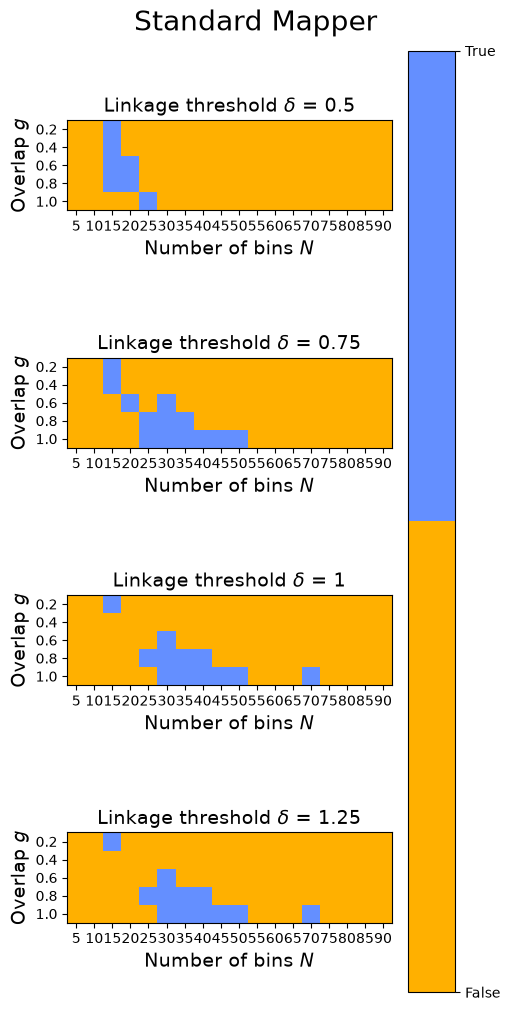

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#FFB000","#648FFF"])

fig, axes = plt.subplots(
    len(delta_values),1,
    figsize=(5, 2.5*len(delta_values)),
    constrained_layout=True
)

# Handle the single-delta case
if len(delta_values) == 1:
    axes = [axes]

for ax, delta in zip(axes, delta_values):
    im = ax.imshow(results[delta], cmap=cmap, vmin=0, vmax=1)

    ax.set_yticks(range(len(g_values)))
    ax.set_yticklabels(g_values)
    ax.set_xticks(range(len(N_values)))
    ax.set_xticklabels(N_values)

    ax.set_ylabel(r"Overlap $g$", fontsize=14)
    ax.set_xlabel(r"Number of bins $N$", fontsize=14)
    ax.set_title(fr"Linkage threshold $\delta$ = {delta}", fontsize=14)

# One shared colorbar
cbar = fig.colorbar(im, ax=axes, ticks=[0, 1])
cbar.ax.set_yticklabels(["False", "True"])
plt.suptitle("Standard Mapper", fontsize=20)
plt.savefig("figures/heatmap-genus1.png")
plt.show()

In [19]:
from tqdm import tqdm
N_values = [5+i*5 for i in range(18)]
density_results = {}

for delta in delta_values:
    heatmap = np.zeros((len(g_values), len(N_values)), dtype=int)
    
    for i,j in itertools.product(range(len(N_values)), range(len(g_values)), desc=f'Delta={delta}'):
        n = N_values[i]   
        g = g_values[j]
        heatmap[j, i] = int(test_mapper_correctness(n, g, delta, density_based=True))
    
    density_results[delta] = heatmap

Delta=0.5:   0%|          | 0/90 [00:00<?, ?it/s]

/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: b

Delta=0.75:   0%|          | 0/90 [00:00<?, ?it/s]

/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: b

Delta=1:   0%|          | 0/90 [00:00<?, ?it/s]

/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: b

Delta=1.25:   0%|          | 0/90 [00:00<?, ?it/s]

/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: build() is deprecated and will be removed in a future version. Please use fit() instead for sklearn-compatible API.
  TG.build()
/tmp/ipykernel_23250/4249830752.py:21: DeprecationWarning: b

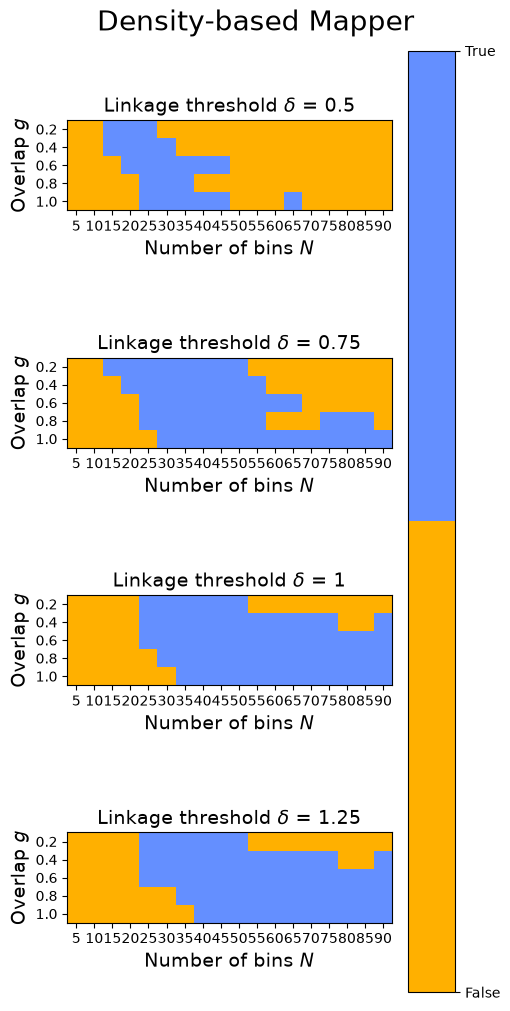

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#FFB000","#648FFF"])

fig, axes = plt.subplots(
    len(delta_values), 1,
    figsize=(5 , 2.5* len(delta_values)),
    constrained_layout=True
)

# Handle the single-delta case
if len(delta_values) == 1:
    axes = [axes]

for ax, delta in zip(axes, delta_values):
    im = ax.imshow(density_results[delta], cmap=cmap, vmin=0, vmax=1)

    ax.set_yticks(range(len(g_values)))
    ax.set_yticklabels(g_values)
    ax.set_xticks(range(len(N_values)))
    ax.set_xticklabels(N_values)

    ax.set_ylabel(r"Overlap $g$", fontsize=14)
    ax.set_xlabel(r"Number of bins $N$", fontsize=14)
    ax.set_title(fr"Linkage threshold $\delta$ = {delta}",fontsize=14)

#One shared colorbar
cbar = fig.colorbar(im, ax=axes, ticks=[0, 1])
cbar.ax.set_yticklabels(["False", "True"])
plt.suptitle("Density-based Mapper", fontsize=20)
plt.savefig("figures/heatmap-genus1-db.png")
plt.show()

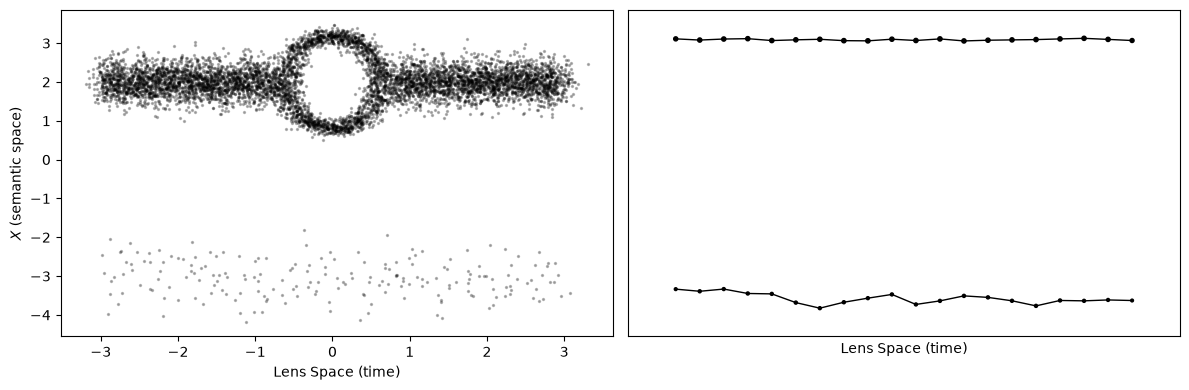

In [ ]:
TG = tm.TemporalMapper(
    timestamps,
    map_data,
    clusterer,
    n_slices = 20,
    neighbours = 50,
    slice_method='time',
    overlap = 0.6,
    density_based=True,
    kernel=tmwc.square,
)
TG.build()


fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[1] = generate_plot(TG, ax=axes[1], label_edges=False)

axes[0].scatter(
    timestamps,
    map_data,
    c='k',
    alpha=0.25,
    s=2,
)
axes[1].set_xlabel("Lens Space (time)")
axes[0].set_xlabel("Lens Space (time)")
axes[0].set_ylabel(r"$X$ (semantic space)")
plt.tight_layout()
plt.savefig("figures/2panel_g1.png")
plt.show()